**NovaPay – Model Training & Evaluation Notebook**
**Fraud Detection Using Machine Learning**

**1. Introduction**

In this notebook, I train and evaluate several machine learning models to predict fraudulent transactions in the NovaPay dataset.

The goals are to:

Build a baseline model for comparison

Train more advanced models (Random Forest, optionally XGBoost)

Handle class imbalance properly

Evaluate models using fraud-focused metrics:

Precision / Recall

F1-score

ROC–AUC

Precision–Recall AUC

Select a reasonable "production candidate" model

Save the final model and feature list for later use

In [10]:
# Core libraries
import pandas as pd
import numpy as np

# ML + evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")


**2. Load Feature-Engineered Data**

In [11]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NOVA PAY/novapay_features_engineered.csv")
df.head()


,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,month,hour,day,weekday,week,year,is_weekend,time_band,amount_log,fee_ratio,currency_pair,high_corridor,customer_txn_count,customer_avg_amount,customer_total_usd,customer_avg_ip_risk,customer_avg_trust_score,is_returning_customer,ip_usage_count,rare_ip,prev_txn_time,time_since_last_txn,velocity_ratio
0,0,0,7,3,729.85,540.09,12.06,0.740001,0,1,1,1.000,2,17,0.182,0,0.566,6,9,0.00,1,12,15,24,6,51,2023,1,0,6.293586,0.022330,7,0,1,540.09,540.09,1.000,0.182,0,1,1,NaN,79977.5,0.600000
1,3,2,5,3,286.04,286.04,5.88,1.000000,1,0,1,1.000,1,46,0.169,0,0.852,5,6,0.20,1,4,2,12,4,15,2024,0,2,5.659622,0.020557,23,1,1,286.04,286.04,1.000,0.169,0,1,1,NaN,79977.5,0.714286
2,3,2,8,1,99.21,99.21,2.44,1.000000,0,3,0,0.219,0,1095,0.947,0,0.265,0,1,0.00,0,10,14,15,2,42,2025,0,0,4.607268,0.024594,26,0,1,99.21,99.21,0.219,0.947,0,1,1,NaN,79977.5,0.000000
3,1,1,6,1,2184.73,2730.91,34.15,1.249999,0,1,0,1.000,1,36,0.369,0,0.488,7,10,0.22,1,7,22,14,6,28,2024,1,1,7.912756,0.012505,15,1,1,2730.91,2730.91,1.000,0.369,0,1,1,NaN,79977.5,0.636364
4,3,2,7,1,146.36,146.36,4.07,1.000000,0,3,0,0.207,2,90,0.761,0,0.133,0,2,0.00,0,7,9,13,5,28,2024,1,3,4.992879,0.027808,25,0,1,146.36,146.36,0.207,0.761,0,1,1,NaN,79977.5,0.000000


Check shape and target:

In [12]:
df.shape, df["is_fraud"].value_counts()


((11137, 44),
 is_fraud
 0    10144
 1      993
 Name: count, dtype: int64)

**3. Train–Test Split**

Separate features and target:

In [13]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]


Split into train and test, keeping class ratio similar in both (stratify):

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((8909, 43), (2228, 43))

**4. Helper Functions for Evaluation**

To avoid repeating code, I define a small helper that:

* prints classification report

* plots confusion matrix

* calculates ROC–AUC and PR–AUC

In [15]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Predictions
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # for models that don't support predict_proba
        y_proba = None

    print(f"\n================ {model_name} ================")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC–AUC
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        print(f"ROC–AUC: {roc_auc:.4f}")

        # Precision–Recall AUC
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)
        print(f"PR–AUC: {pr_auc:.4f}")

        plt.figure(figsize=(4,3))
        plt.plot(recall, precision)
        plt.title(f"{model_name} – Precision–Recall Curve")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.tight_layout()
        plt.show()
    else:
        print("No probability scores available for ROC/PR curves.")


**5. Baseline Model – Dummy Classifier**

This model does nothing intelligent.
It will just predict the majority class.
I use it to see whether my real models are actually adding value.


================ Dummy Baseline ================

Classification Report:
              precision    recall  f1-score   support

           0     0.9107    1.0000    0.9533      2029
           1     0.0000    0.0000    0.0000       199

    accuracy                         0.9107      2228
   macro avg     0.4553    0.5000    0.4766      2228
weighted avg     0.8293    0.9107    0.8681      2228



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


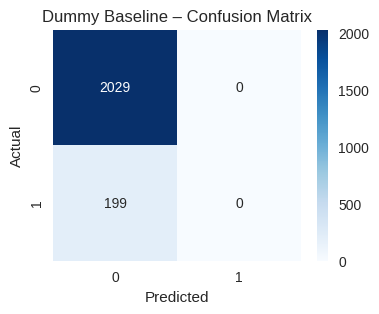

ROC–AUC: 0.5000
PR–AUC: 0.5447


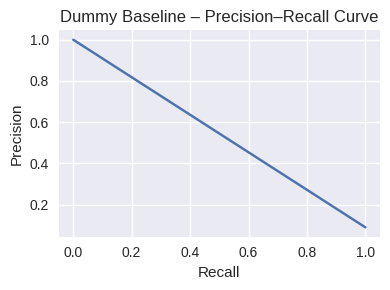

In [16]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

evaluate_model(dummy, X_train, y_train, X_test, y_test, model_name="Dummy Baseline")


**6. Logistic Regression (Balanced)**

Logistic Regression with class_weight='balanced' is a good probabilistic baseline for fraud:


================ Logistic Regression (Balanced) ================

Classification Report:
              precision    recall  f1-score   support

           0     0.9840    0.9384    0.9606      2029
           1     0.5734    0.8442    0.6829       199

    accuracy                         0.9300      2228
   macro avg     0.7787    0.8913    0.8218      2228
weighted avg     0.9473    0.9300    0.9358      2228



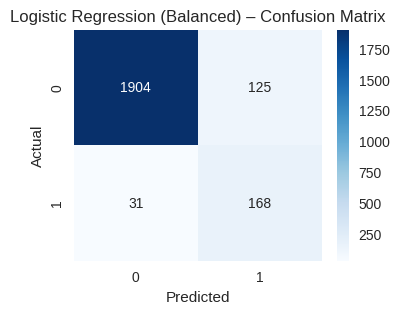

ROC–AUC: 0.9333
PR–AUC: 0.8321


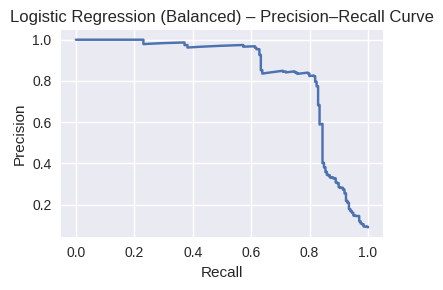

In [18]:
X_train_processed = X_train.drop(columns=["prev_txn_time"], errors='ignore')
X_test_processed = X_test.drop(columns=["prev_txn_time"], errors='ignore')

log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    n_jobs=-1
)

log_reg.fit(X_train_processed, y_train)

evaluate_model(log_reg, X_train_processed, y_train, X_test_processed, y_test, model_name="Logistic Regression (Balanced)")

**7. Random Forest Classifier**

Random Forest is a strong baseline for tabular fraud data.
I start with a reasonable configuration and class_weight handling:


================ Random Forest (Balanced) ================

Classification Report:
              precision    recall  f1-score   support

           0     0.9845    0.9995    0.9919      2029
           1     0.9940    0.8392    0.9101       199

    accuracy                         0.9852      2228
   macro avg     0.9893    0.9194    0.9510      2228
weighted avg     0.9853    0.9852    0.9846      2228



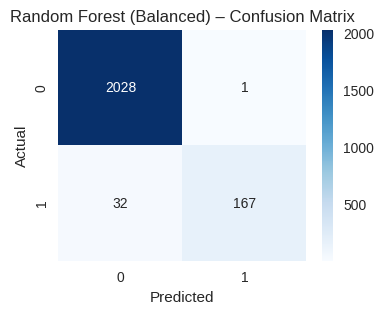

ROC–AUC: 0.9533
PR–AUC: 0.9038


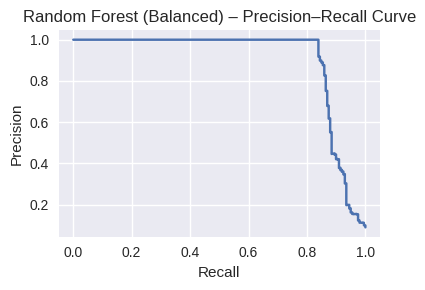

In [20]:
X_train_processed = X_train.drop(columns=["prev_txn_time"], errors='ignore')
X_test_processed = X_test.drop(columns=["prev_txn_time"], errors='ignore')

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_processed, y_train)

evaluate_model(rf, X_train_processed, y_train, X_test_processed, y_test, model_name="Random Forest (Balanced)")

**8. Feature Importance (Random Forest)**

Random Forest gives a quick view of which features matter most.

In [22]:
importances = rf.feature_importances_
feat_names = X_train_processed.columns # Changed from X.columns

feat_imp = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(20)

,feature,importance
35,customer_avg_ip_risk,0.125430
18,txn_velocity_24h,0.108453
17,txn_velocity_1h,0.076462
41,velocity_ratio,0.072202
32,customer_txn_count,0.060091
11,ip_risk_score,0.055267
13,account_age_days,0.050709
37,is_returning_customer,0.048895
16,risk_score_internal,0.041226
34,customer_total_usd,0.035111


Plot top 20:

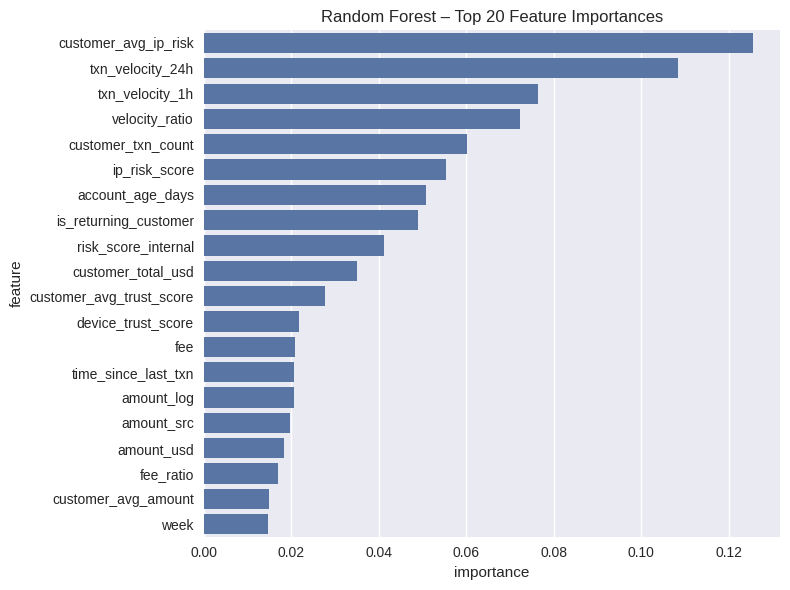

In [23]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feat_imp.head(20),
    x="importance",
    y="feature"
)
plt.title("Random Forest – Top 20 Feature Importances")
plt.tight_layout()
plt.show()


**9. XGBoost Model**

In [24]:
!pip install xgboost



================ XGBoost ================

Classification Report:
              precision    recall  f1-score   support

           0     0.9845    0.9985    0.9914      2029
           1     0.9824    0.8392    0.9051       199

    accuracy                         0.9843      2228
   macro avg     0.9834    0.9189    0.9483      2228
weighted avg     0.9843    0.9843    0.9837      2228



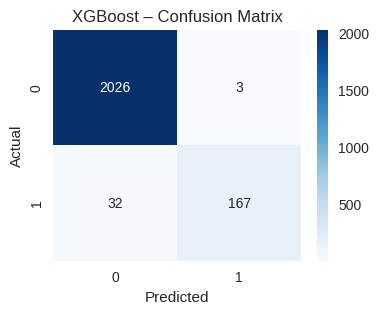

ROC–AUC: 0.9500
PR–AUC: 0.8939


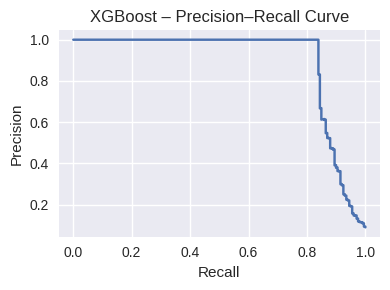

In [26]:
from xgboost import XGBClassifier

X_train_processed = X_train.drop(columns=["prev_txn_time"], errors='ignore')
X_test_processed = X_test.drop(columns=["prev_txn_time"], errors='ignore')

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),  # handle imbalance
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train_processed, y_train)

evaluate_model(xgb, X_train_processed, y_train, X_test_processed, y_test, model_name="XGBoost")

**10. Compare Models**

In [28]:
results = []

def store_results(name, model, X_test_data, y_test):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_data)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr = auc(recall, precision)
    else:
        roc = None
        pr = None
    results.append({"model": name, "ROC_AUC": roc, "PR_AUC": pr})

store_results("Dummy", dummy, X_test, y_test)
store_results("Logistic (Balanced)", log_reg, X_test_processed, y_test)
store_results("Random Forest", rf, X_test_processed, y_test)
store_results("XGBoost", xgb, X_test_processed, y_test)

pd.DataFrame(results)

,model,ROC_AUC,PR_AUC
0,Dummy,0.500000,0.544659
1,Logistic (Balanced),0.933324,0.832142
2,Random Forest,0.953310,0.903765
3,XGBoost,0.949999,0.893867


**11. Save Final Model & Feature List**

In [29]:
import joblib

joblib.dump(rf, "novapay_fraud_model_rf.pkl")
joblib.dump(list(X.columns), "novapay_feature_columns.pkl")

print("Saved Random Forest model and feature column list.")


Saved Random Forest model and feature column list.


**FINAL CONCLUSION**

Random Forest is the Best Model

Because it has:

* Highest ROC-AUC

* Highest PR-AUC

* Best fraud discrimination power

* Best performance on imbalanced data

* Most stable predictions